Loading model from: /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/DAPORINAD_NAMPT_forgeModel_optuna100_321456.pkl
Loading Expression, Dependency, and IC50 data...
Common cell lines found: 700
Final Data Shapes -> Exp: (697, 198), Dep: (697,), IC50: (697,)


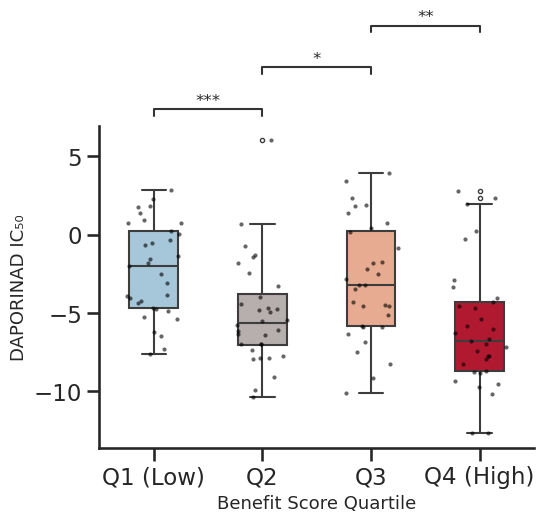

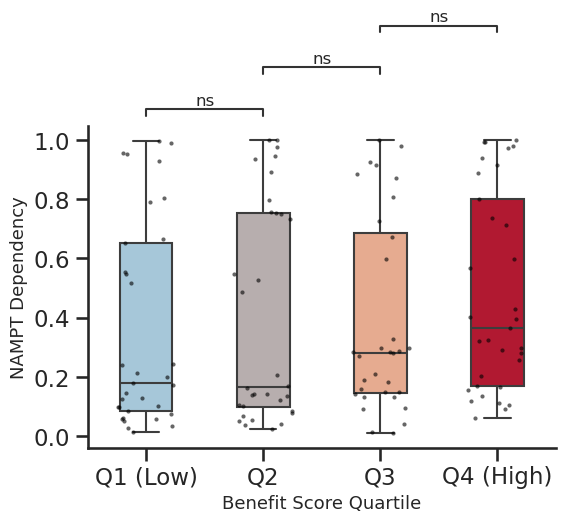

Processing complete. Plots saved.


In [5]:
# ===============================
# 0. Imports & plotting setup
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pickle
import os
from scipy.stats import kruskal
from statannotations.Annotator import Annotator
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
# ===============================
# 1. Load the Model
# ===============================
model_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/DAPORINAD_NAMPT_forgeModel_optuna100_321456.pkl"
print(f"Loading model from: {model_path}")
with open(model_path, "rb") as f:
    model = pickle.load(f)
# ===============================
# 2. Data Preparation & Alignment
# ===============================
print("Loading Expression, Dependency, and IC50 data...")
exp_data = pd.read_csv(model.exp_path, header=0, index_col=0)
dep_data = pd.read_csv(model.dep_path, header=0, index_col=0)
ic50_data = pd.read_csv(model.ic50_path, header=0, index_col=0).T
common_cellLines = list(set(exp_data.index) & set(dep_data.index) & set(ic50_data.index))
print(f"Common cell lines found: {len(common_cellLines)}")
# Filter for target gene and drug
exp_data_subset = exp_data.loc[common_cellLines, model.hcg_list].drop_duplicates(keep='first')
dep_target = dep_data.loc[common_cellLines, model.target].dropna().drop_duplicates(keep='first')
drug_ic50 = ic50_data.loc[common_cellLines, model.drug].dropna().drop_duplicates(keep='first')
# Re-align to dependency index
exp_data_subset = exp_data.loc[dep_target.index, model.hcg_list]
drug_ic50 = ic50_data.loc[dep_target.index, model.drug]
print(f"Final Data Shapes -> Exp: {exp_data_subset.shape}, Dep: {dep_target.shape}, IC50: {drug_ic50.shape}")
# ===============================
# 3. Train / Test Splitting
# ===============================
common_train_cellLines = list(set(model.train_cellLines) & set(exp_data_subset.index))
common_test_cellLines = list(set(model.test_cellLines) & set(exp_data_subset.index))
G_train = exp_data_subset.loc[common_train_cellLines, :].to_numpy()
G_test  = exp_data_subset.loc[common_test_cellLines, :].to_numpy()
D_train = dep_target.loc[common_train_cellLines].to_numpy().reshape(-1, 1)
D_test  = dep_target.loc[common_test_cellLines].to_numpy().reshape(-1, 1)
I_train = drug_ic50.loc[common_train_cellLines].to_numpy().reshape(-1, 1)
I_test  = drug_ic50.loc[common_test_cellLines].to_numpy().reshape(-1, 1)
# ===============================
# 4. Latent Factor Calculations & Predictions
# ===============================
Z_train = G_train @ model.W
Z_test  = G_test  @ model.W
pred_D_train = Z_train @ model.hD
pred_D_test  = Z_test  @ model.hD
pred_I_train = Z_train @ model.hI
pred_I_test  = Z_test  @ model.hI
# Benefit Score = Predicted Dependency - Predicted IC50
benefit_train = pred_D_train - pred_I_train
benefit_test  = pred_D_test - pred_I_test
# ===============================
# 5. Build DataFrame for Plotting (Test Set)
# ===============================
df_test_plot = pd.DataFrame({
    "IC50": I_test.flatten(),
    f"{model.target} Dependency": D_test.flatten(),
    "Benefit Score": benefit_test.flatten()
})
df_test_plot["Benefit Score Bin"] = pd.qcut(
    df_test_plot["Benefit Score"],
    q=4,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)
# ===============================
# 6. Visualization & Statistics
# ===============================
save_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig5"
os.makedirs(save_path, exist_ok=True)
sns.set(style="white", context="talk")
palette = ['#9ecae1', "#b8adad", '#f4a582', '#ca0020']
box_width = 0.45
pairs = [("Q1 (Low)", "Q2"), ("Q2", "Q3"), ("Q3", "Q4 (High)")]
# --- Plot 1: IC50 Boxplot ---
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y="IC50",
    palette=palette,
    width=box_width,
    linewidth=1.5,
    fliersize=3,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"],
    hue="Benefit Score Bin",
    legend=False
)
sns.stripplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y="IC50",
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.6,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)
annotator = Annotator(ax, pairs, data=df_test_plot, x="Benefit Score Bin", y="IC50",
                      order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
annotator.configure(test="Mann-Whitney", text_format='star', loc='outside',
                    comparisons_correction=None, verbose=0)
annotator.apply_and_annotate()
for text in ax.texts:
    text.set_fontsize(12)
sns.despine(top=True, right=True)
plt.xlabel("Benefit Score Quartile", fontsize=13)
plt.ylabel(f"{model.drug} IC₅₀", fontsize=13)
plt.tick_params(axis='both', which='both', bottom=True, left=True)
plt.tight_layout()
plt.savefig(os.path.join(save_path, "IC50_boxplot_testset_Daporinad.pdf"))
plt.show()
# --- Plot 2: Dependency Boxplot ---
dep_col_name = f"{model.target} Dependency"
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y=dep_col_name,
    palette=palette,
    width=box_width,
    linewidth=1.5,
    fliersize=3,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"],
    hue="Benefit Score Bin",
    legend=False
)
sns.stripplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y=dep_col_name,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.6,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)
annotator = Annotator(ax, pairs, data=df_test_plot, x="Benefit Score Bin", y=dep_col_name,
                      order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
annotator.configure(test="Mann-Whitney", text_format='star', loc='outside',
                    comparisons_correction=None, verbose=0)
annotator.apply_and_annotate()
for text in ax.texts:
    text.set_fontsize(12)
sns.despine(top=True, right=True)
plt.xlabel("Benefit Score Quartile", fontsize=13)
plt.ylabel(f"{model.target} Dependency", fontsize=13)
plt.tick_params(axis='both', which='both', bottom=True, left=True)
plt.tight_layout()
#plt.savefig(os.path.join(save_path, "Dependency_boxplot_testset_Daporinad.pdf"))
plt.show()
print("Processing complete. Plots saved.")

In [6]:
from scipy.stats import mannwhitneyu
def compute_stats(x, y, alternative = 'two-sided'):
    U, p = mannwhitneyu(x, y, alternative=alternative)
    n1, n2 = len(x), len(y)
    rbc = 1 - (2 * U) / (n1 * n2)
    return U, p, rbc

# ---- Dependency stats (Test set) ----
U, p, rbc = compute_stats(
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q1 (Low)'][f'{model.target} Dependency'],
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q2'][f'{model.target} Dependency'], alternative='greater'
)
print(f"Test {model.target} Dependency: Q1 vs Q2 -> U={U:.1f}, p={p:.2e}, rbc={rbc:.2f}")
U, p, rbc = compute_stats(
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q2'][f'{model.target} Dependency'],
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q3'][f'{model.target} Dependency'], alternative='greater'    
)
print(f"Test {model.target} Dependency: Q2 vs Q3 -> U={U:.1f}, p={p:.2e}, rbc={rbc:.2f}")
U, p, rbc = compute_stats(
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q3'][f'{model.target} Dependency'],
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q4 (High)'][f'{model.target} Dependency'], alternative='greater'
)
print(f"Test {model.target} Dependency: Q3 vs Q4 -> U={U:.1f}, p={p:.2e}, rbc={rbc:.2f}")
# ---- IC50 stats (Test set) ----
U, p, rbc = compute_stats(
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q1 (Low)']['IC50'],
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q2']['IC50'], alternative='greater'
)
print(f"Test IC50: Q1 vs Q2 -> U={U:.1f}, p={p:.2e}, rbc={rbc:.2f}")
U, p, rbc = compute_stats(
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q2']['IC50'],
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q3']['IC50'], alternative='greater'
)
print(f"Test IC50: Q2 vs Q3 -> U={U:.1f}, p={p:.2e}, rbc={rbc:.2f}")
U, p, rbc = compute_stats(
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q3']['IC50'],
    df_test_plot[df_test_plot['Benefit Score Bin'] == 'Q4 (High)']['IC50'], alternative='greater'
)
print(f"Test IC50: Q3 vs Q4 -> U={U:.1f}, p={p:.2e}, rbc={rbc:.2f}")

Test NAMPT Dependency: Q1 vs Q2 -> U=500.0, p=6.46e-01, rbc=0.05
Test NAMPT Dependency: Q2 vs Q3 -> U=471.0, p=7.11e-01, rbc=0.08
Test NAMPT Dependency: Q3 vs Q4 -> U=424.0, p=9.15e-01, rbc=0.20
Test IC50: Q1 vs Q2 -> U=809.0, p=1.16e-04, rbc=-0.53
Test IC50: Q2 vs Q3 -> U=326.0, p=9.94e-01, rbc=0.36
Test IC50: Q3 vs Q4 -> U=768.0, p=8.37e-04, rbc=-0.45
